# **Taller Práctico 2**
## **Múltiples filtros de imágenes aplicados al procesamiento de video con CUDA**

**Asignatura:** Métricas / Procesamiento de Imágenes  
**Universidad:** Universidad Sergio Arboleda  

**Integrantes:**

- Dylan Cifuentes  
- Jonathan Peña  
- Steeven Garzón  

**Fecha:** Marzo 2026

---

### **Descripción**

En este laboratorio se implementan cinco filtros de procesamiento de imágenes utilizando
paralelización mediante CUDA. A diferencia del taller anterior, donde los filtros se
aplicaban a imágenes individuales, en este trabajo los algoritmos se extienden al
procesamiento de video, considerando el video como una secuencia de frames.

Cada frame es procesado de forma independiente en la GPU mediante kernels CUDA
implementados para los siguientes filtros:

1. Inversión de colores (Negativo)
2. Blur (Desenfoque)
3. Recorte de imagen
4. Imagen binaria (Threshold)
5. Detección de bordes mediante operador Sobel

El flujo general del sistema consiste en:

Video → extracción de frames → procesamiento CUDA → reconstrucción del video.

## **Instalación de librerías**

In [ ]:
!pip install numba opencv-python-headless imageio imageio-ffmpeg matplotlib -q

In [ ]:
import os
import math
import cv2
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt

from numba import cuda
from google.colab import files

## **Video**

In [ ]:
uploaded = files.upload()
video_name = list(uploaded.keys())[0]
print("Video cargado:", video_name)

Saving Video_Prueba_02.mp4 to Video_Prueba_02.mp4
Video cargado: Video_Prueba_02.mp4


## **Kernels CUDA de los 5 filtros**

In [ ]:
# =========================================
# 1. NEGATIVO
# =========================================
@cuda.jit
def negative_kernel(img_in, img_out):
    y, x = cuda.grid(2)

    if y < img_in.shape[0] and x < img_in.shape[1]:
        for c in range(3):
            img_out[y, x, c] = 255 - img_in[y, x, c]


# =========================================
# 2. BLUR con clamping
# =========================================
@cuda.jit
def blur_kernel(img_in, img_out, radius):
    y, x = cuda.grid(2)

    h = img_in.shape[0]
    w = img_in.shape[1]

    if y < h and x < w:
        count = 0
        sum0 = 0
        sum1 = 0
        sum2 = 0

        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                ny = y + dy
                nx = x + dx

                # clamping
                if ny < 0:
                    ny = 0
                elif ny >= h:
                    ny = h - 1

                if nx < 0:
                    nx = 0
                elif nx >= w:
                    nx = w - 1

                sum0 += img_in[ny, nx, 0]
                sum1 += img_in[ny, nx, 1]
                sum2 += img_in[ny, nx, 2]
                count += 1

        img_out[y, x, 0] = sum0 // count
        img_out[y, x, 1] = sum1 // count
        img_out[y, x, 2] = sum2 // count


# =========================================
# 3. CROP
# =========================================
@cuda.jit
def crop_kernel(img_in, img_out, x_start, y_start):
    y, x = cuda.grid(2)

    if y < img_out.shape[0] and x < img_out.shape[1]:
        src_y = y + y_start
        src_x = x + x_start

        if src_y < img_in.shape[0] and src_x < img_in.shape[1]:
            for c in range(3):
                img_out[y, x, c] = img_in[src_y, src_x, c]


# =========================================
# 4. BINARIA
# =========================================
@cuda.jit
def binary_kernel(img_in, img_out, threshold):
    y, x = cuda.grid(2)

    if y < img_in.shape[0] and x < img_in.shape[1]:
        b = img_in[y, x, 0]
        g = img_in[y, x, 1]
        r = img_in[y, x, 2]

        gray = (int(r) + int(g) + int(b)) // 3
        value = 255 if gray > threshold else 0

        img_out[y, x, 0] = value
        img_out[y, x, 1] = value
        img_out[y, x, 2] = value


# =========================================
# 5. SOBEL
# =========================================
@cuda.jit
def sobel_kernel(img_in, img_out):
    y, x = cuda.grid(2)

    h = img_in.shape[0]
    w = img_in.shape[1]

    if 1 <= y < h - 1 and 1 <= x < w - 1:
        gx = 0
        gy = 0

        # vecinos en gris
        for j in range(-1, 2):
            for i in range(-1, 2):
                b = img_in[y + j, x + i, 0]
                g = img_in[y + j, x + i, 1]
                r = img_in[y + j, x + i, 2]
                gray = (int(r) + int(g) + int(b)) // 3

                # kernel Gx
                if j == -1 and i == -1:
                    kx = -1
                    ky = -1
                elif j == -1 and i == 0:
                    kx = 0
                    ky = -2
                elif j == -1 and i == 1:
                    kx = 1
                    ky = -1
                elif j == 0 and i == -1:
                    kx = -2
                    ky = 0
                elif j == 0 and i == 0:
                    kx = 0
                    ky = 0
                elif j == 0 and i == 1:
                    kx = 2
                    ky = 0
                elif j == 1 and i == -1:
                    kx = -1
                    ky = 1
                elif j == 1 and i == 0:
                    kx = 0
                    ky = 2
                else:  # j == 1 and i == 1
                    kx = 1
                    ky = 1

                gx += gray * kx
                gy += gray * ky

        gval = int(math.sqrt(gx * gx + gy * gy))

        if gval > 255:
            gval = 255
        elif gval < 0:
            gval = 0

        img_out[y, x, 0] = gval
        img_out[y, x, 1] = gval
        img_out[y, x, 2] = gval

    elif y < h and x < w:
        img_out[y, x, 0] = 0
        img_out[y, x, 1] = 0
        img_out[y, x, 2] = 0

## **Funciones auxiliares para aplicar filtros a un frame**

In [ ]:
TPB = (16, 16)

def get_grid_dims(height, width):
    blocks_y = (height + TPB[0] - 1) // TPB[0]
    blocks_x = (width + TPB[1] - 1) // TPB[1]
    return (blocks_y, blocks_x)

def apply_negative_cuda(frame):
    h, w, _ = frame.shape
    d_in = cuda.to_device(frame)
    d_out = cuda.device_array_like(frame)

    BPG = get_grid_dims(h, w)
    negative_kernel[BPG, TPB](d_in, d_out)

    return d_out.copy_to_host()

def apply_blur_cuda(frame, radius=1):
    h, w, _ = frame.shape
    d_in = cuda.to_device(frame)
    d_out = cuda.device_array_like(frame)

    BPG = get_grid_dims(h, w)
    blur_kernel[BPG, TPB](d_in, d_out, radius)

    return d_out.copy_to_host()

def apply_crop_cuda(frame, x_start, y_start, crop_width, crop_height):
    h, w, _ = frame.shape

    if x_start < 0 or y_start < 0:
        raise ValueError("x_start y y_start deben ser >= 0")
    if x_start + crop_width > w or y_start + crop_height > h:
        raise ValueError("La ROI del recorte se sale de la imagen original")

    out = np.zeros((crop_height, crop_width, 3), dtype=np.uint8)

    d_in = cuda.to_device(frame)
    d_out = cuda.to_device(out)

    BPG = get_grid_dims(crop_height, crop_width)
    crop_kernel[BPG, TPB](d_in, d_out, x_start, y_start)

    return d_out.copy_to_host()

def apply_binary_cuda(frame, threshold=128):
    h, w, _ = frame.shape
    d_in = cuda.to_device(frame)
    d_out = cuda.device_array_like(frame)

    BPG = get_grid_dims(h, w)
    binary_kernel[BPG, TPB](d_in, d_out, threshold)

    return d_out.copy_to_host()

def apply_sobel_cuda(frame):
    h, w, _ = frame.shape
    d_in = cuda.to_device(frame)
    d_out = cuda.device_array_like(frame)

    BPG = get_grid_dims(h, w)
    sobel_kernel[BPG, TPB](d_in, d_out)

    return d_out.copy_to_host()

## **Función general para procesar el video completo**

In [ ]:
def process_video_cuda(
    input_video,
    output_video,
    filter_name="negative",
    radius=1,
    threshold=128,
    x_start=0,
    y_start=0,
    crop_width=None,
    crop_height=None,
    max_frames=None
):
    cap = cv2.VideoCapture(input_video)

    if not cap.isOpened():
        raise ValueError("No se pudo abrir el video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    orig_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if fps <= 0:
        fps = 24

    # tamaño de salida
    if filter_name == "crop":
        if crop_width is None or crop_height is None:
            raise ValueError("Para crop debes definir crop_width y crop_height")
        out_width = crop_width
        out_height = crop_height
    else:
        out_width = orig_width
        out_height = orig_height

    # writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video, fourcc, fps, (out_width, out_height))

    processed = 0

    print(f"FPS: {fps}")
    print(f"Frames totales reportados: {total_frames}")
    print(f"Resolución original: {orig_width}x{orig_height}")
    print(f"Filtro seleccionado: {filter_name}")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # frame llega en BGR con OpenCV
        if filter_name == "negative":
            frame_out = apply_negative_cuda(frame)

        elif filter_name == "blur":
            frame_out = apply_blur_cuda(frame, radius=radius)

        elif filter_name == "crop":
            frame_out = apply_crop_cuda(
                frame,
                x_start=x_start,
                y_start=y_start,
                crop_width=crop_width,
                crop_height=crop_height
            )

        elif filter_name == "binary":
            frame_out = apply_binary_cuda(frame, threshold=threshold)

        elif filter_name == "sobel":
            frame_out = apply_sobel_cuda(frame)

        else:
            raise ValueError("Filtro no válido. Usa: negative, blur, crop, binary, sobel")

        out.write(frame_out)
        processed += 1

        if processed % 30 == 0:
            print(f"Procesados: {processed} frames")

        if max_frames is not None and processed >= max_frames:
            break

    cap.release()
    out.release()

    print(f"\nVideo procesado guardado en: {output_video}")
    print(f"Total de frames procesados: {processed}")

## **Filtros**

### **A. Negativo**

In [ ]:
process_video_cuda(
    input_video=video_name,
    output_video="video_negativo.mp4",
    filter_name="negative"
)

files.download("video_negativo.mp4")

FPS: 30.0
Frames totales reportados: 446
Resolución original: 1080x1920
Filtro seleccionado: negative
Procesados: 30 frames
Procesados: 60 frames
Procesados: 90 frames
Procesados: 120 frames
Procesados: 150 frames
Procesados: 180 frames
Procesados: 210 frames
Procesados: 240 frames
Procesados: 270 frames
Procesados: 300 frames
Procesados: 330 frames
Procesados: 360 frames
Procesados: 390 frames
Procesados: 420 frames

Video procesado guardado en: video_negativo.mp4
Total de frames procesados: 446


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **B. Blur**

In [ ]:
process_video_cuda(
    input_video=video_name,
    output_video="video_blur.mp4",
    filter_name="blur",
    radius=10
)

files.download("video_blur.mp4")

FPS: 30.0
Frames totales reportados: 446
Resolución original: 1080x1920
Filtro seleccionado: blur
Procesados: 30 frames
Procesados: 60 frames
Procesados: 90 frames
Procesados: 120 frames
Procesados: 150 frames
Procesados: 180 frames
Procesados: 210 frames
Procesados: 240 frames
Procesados: 270 frames
Procesados: 300 frames
Procesados: 330 frames
Procesados: 360 frames
Procesados: 390 frames
Procesados: 420 frames

Video procesado guardado en: video_blur.mp4
Total de frames procesados: 446


### **C. Recorte**

In [ ]:
process_video_cuda(
    input_video=video_name,
    output_video="video_crop.mp4",
    filter_name="crop",
    x_start=100,
    y_start=50,
    crop_width=400,
    crop_height=300
)

files.download("video_crop.mp4")

FPS: 30.0
Frames totales reportados: 446
Resolución original: 1080x1920
Filtro seleccionado: crop
Procesados: 30 frames
Procesados: 60 frames
Procesados: 90 frames
Procesados: 120 frames
Procesados: 150 frames
Procesados: 180 frames
Procesados: 210 frames
Procesados: 240 frames
Procesados: 270 frames
Procesados: 300 frames
Procesados: 330 frames
Procesados: 360 frames
Procesados: 390 frames
Procesados: 420 frames

Video procesado guardado en: video_crop.mp4
Total de frames procesados: 446


### **D. Binaria**

In [ ]:
process_video_cuda(
    input_video=video_name,
    output_video="video_binario.mp4",
    filter_name="binary",
    threshold=128
)

files.download("video_binario.mp4")

FPS: 30.0
Frames totales reportados: 446
Resolución original: 1080x1920
Filtro seleccionado: binary
Procesados: 30 frames
Procesados: 60 frames
Procesados: 90 frames
Procesados: 120 frames
Procesados: 150 frames
Procesados: 180 frames
Procesados: 210 frames
Procesados: 240 frames
Procesados: 270 frames
Procesados: 300 frames
Procesados: 330 frames
Procesados: 360 frames
Procesados: 390 frames
Procesados: 420 frames

Video procesado guardado en: video_binario.mp4
Total de frames procesados: 446


### **E. Sobel**

In [ ]:
process_video_cuda(
    input_video=video_name,
    output_video="video_sobel.mp4",
    filter_name="sobel"
)

files.download("video_sobel.mp4")

FPS: 30.0
Frames totales reportados: 446
Resolución original: 1080x1920
Filtro seleccionado: sobel
Procesados: 30 frames
Procesados: 60 frames
Procesados: 90 frames
Procesados: 120 frames
Procesados: 150 frames
Procesados: 180 frames
Procesados: 210 frames
Procesados: 240 frames
Procesados: 270 frames
Procesados: 300 frames
Procesados: 330 frames
Procesados: 360 frames
Procesados: 390 frames
Procesados: 420 frames

Video procesado guardado en: video_sobel.mp4
Total de frames procesados: 446


## **Comparación de un frame original vs procesado**

### **Codigo**

In [ ]:
def show_first_frame_comparison(
    input_video,
    filter_name="negative",
    radius=1,
    threshold=128,
    x_start=0,
    y_start=0,
    crop_width=None,
    crop_height=None
):
    cap = cv2.VideoCapture(input_video)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise ValueError("No se pudo leer el primer frame.")

    if filter_name == "negative":
        processed = apply_negative_cuda(frame)
    elif filter_name == "blur":
        processed = apply_blur_cuda(frame, radius=radius)
    elif filter_name == "crop":
        processed = apply_crop_cuda(frame, x_start, y_start, crop_width, crop_height)
    elif filter_name == "binary":
        processed = apply_binary_cuda(frame, threshold=threshold)
    elif filter_name == "sobel":
        processed = apply_sobel_cuda(frame)
    else:
        raise ValueError("Filtro inválido")

    # BGR -> RGB para matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(frame_rgb)
    plt.title("Frame original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(processed_rgb)
    plt.title(f"Frame procesado - {filter_name}")
    plt.axis("off")

    plt.show()

### **A. Negativo**

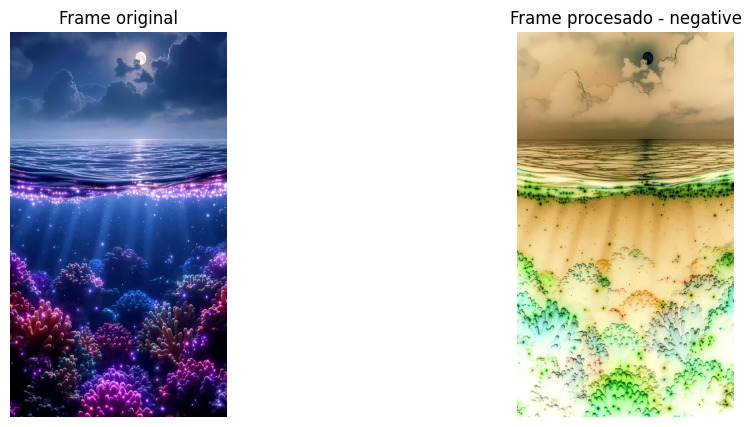

In [ ]:
show_first_frame_comparison(video_name, filter_name="negative")

### **B. Blur**

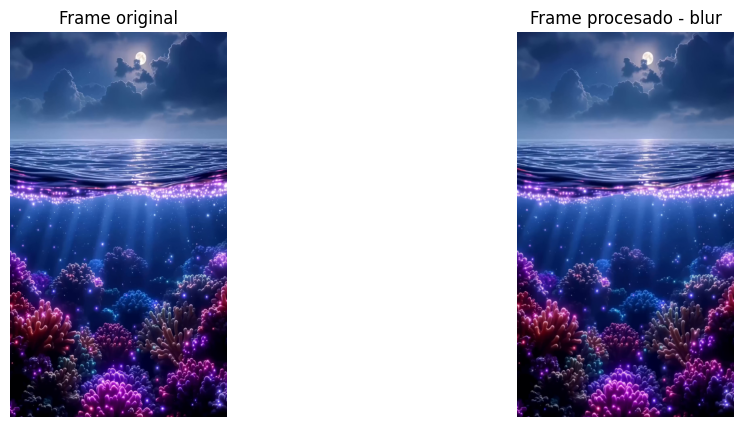

In [ ]:
show_first_frame_comparison(video_name, filter_name="blur")

### **C. Recorte**

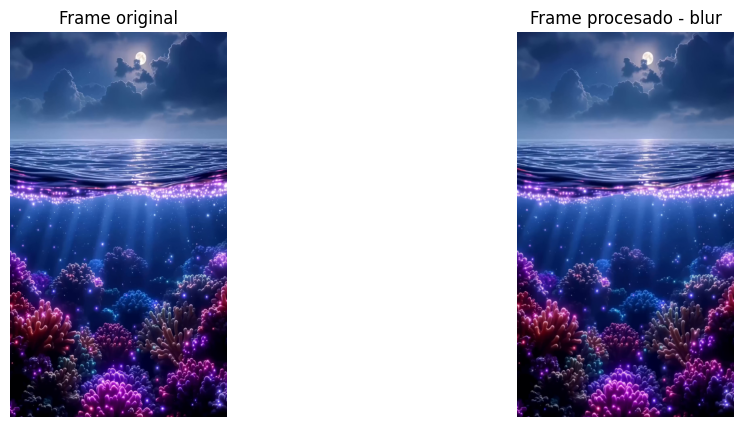

In [ ]:
show_first_frame_comparison(video_name, filter_name="blur")

### **D. Binaria**

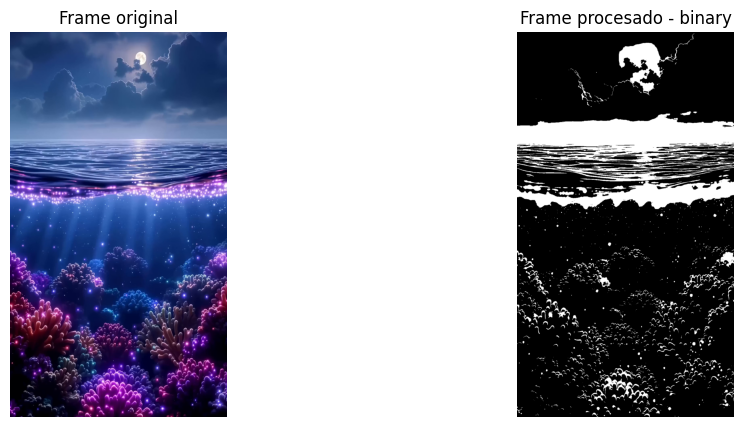

In [ ]:
show_first_frame_comparison(video_name, filter_name="binary")

### **E. Sobel**

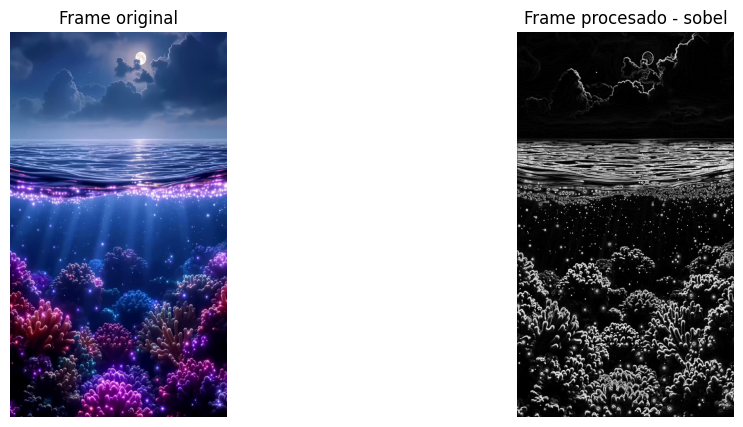

In [ ]:
show_first_frame_comparison(video_name, filter_name="sobel")